# Tune `MultiSupplierTextbookPolicy` Hyperparameters

A tutorial + analysis notebook for the Optuna-based policy tuning tool introduced in
[ADR 0009](../docs/adr/0009-policy-hyperparameter-tuning-tool.md), updated for the
multi-echelon graph engine.

**Framing (measurement instrument, not baseline construction).** The tuning tool answers
"how much headroom does `OrderUpToPolicy` (via `MultiSupplierTextbookPolicy`) have above
its published defaults?" It does *not* change what the published defaults are, and the
canonical RL CRN baseline trajectory is bit-identical before and after a tuning run.

The graph-engine update adds two new tunables:
- `per_supplier_min_order_floor` (int, 0–10): minimum order floor per supplier
- `routing_strategy` (Categorical): multi-supplier routing strategy

The per-trial CRN tuple now includes the `allocation` sub-seed (ADR 0016) so
paired comparisons remain bit-identical on the graph engine.

**Sections:**
1. Setup & motivation
2. The tool in one screen + live smoke demo
3. New tunables: `per_supplier_min_order_floor` and `routing_strategy`
4. Load pre-run study artifacts
5. Optimisation trajectory
6. Parameter sensitivity scatters
7. Pareto front: profit vs service level
8. Scale robustness: per-capacity-bucket paired bar
9. Closing — follow-up directions

## 1. Setup & motivation

In [1]:
%load_ext autoreload
%autoreload 2

import json
import os
import pathlib

# Navigate to repo root so all relative imports work.
while not (pathlib.Path.cwd() / 'pyproject.toml').exists():
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna

from src.tuning import (
    TuningConfig,
    order_up_to_space,
    run_study,
    load_world,
)

# Plot defaults.
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 9

optuna.logging.set_verbosity(optuna.logging.WARNING)

print('Setup complete.')
%matplotlib inline


Setup complete.


In [2]:
# Load catalog and base template from the tuning world cache.
tuning_config_base = TuningConfig()  # defaults to fashion_retail_250
catalog, base_template, market_params, disruption_params = load_world(tuning_config_base)
print(f'Catalog: {len(catalog)} products | world_archetype={tuning_config_base.world_archetype}')

Catalog: 336 products | world_archetype=fashion_retail_250


[sim.world_loader] Loaded world from data/worlds/fashion_retail_250/world.json (336 products).


## 2. The tool in one screen + live smoke demo

The tuning API is five lines: import the search-space factory, build a `TuningConfig`,
call `run_study`. Below we run a tiny smoke demo (5 trials, 4 seeds, 60-tick episodes)
to show the API executing live on the graph engine.

In [3]:
import time

demo_config = TuningConfig(
    n_trials=5,
    n_search_seeds=4,
    episode_length=60,
)

t0 = time.time()
demo_study = run_study(
    order_up_to_space,
    catalog=catalog,
    base_template=base_template,
    tuning_config=demo_config,
    study_name='demo_5_trial_graph',
    output_dir='/tmp/demo_tuning_graph',
    market_params=market_params,
    disruption_params=disruption_params,
)
elapsed = time.time() - t0

print(f'Demo study: {len(demo_study.trials)} trials in {elapsed:.1f}s')
print(f'Best mean normalised return : {demo_study.best_value:.4f}')
print(f'Best params                 : {demo_study.best_trial.params}')

Demo study: 5 trials in 1.9s
Best mean normalised return : 0.3220
Best params                 : {'cover_horizon_ticks': 2, 'safety_lead_pct_of_lag': 2.5985284373248057, 'stockout_safety_bonus_pct_of_lag': 1.2022300234864176, 'per_supplier_min_order_floor': 7, 'routing_strategy': 'fill_rate_weighted'}


## 3. New tunables: `per_supplier_min_order_floor` and `routing_strategy`

The graph-engine search space adds two new parameters to `order_up_to_space`:

- **`per_supplier_min_order_floor`** (int, 0–10): minimum units per supplier line in
  `_split_across_suppliers`. Setting this > 0 avoids tiny "trickle" orders to secondary
  suppliers but reduces routing flexibility when one supplier is nearly out of stock.

- **`routing_strategy`** (Categorical: `"cheapest_first"`, `"fill_rate_weighted"`):
  selects the `_split_across_suppliers` routing strategy. `cheapest_first` (default)
  fills from the cheapest supplier first; `fill_rate_weighted` routes proportionally
  to recent fill-rate EMA — useful when the cheapest supplier is also the most
  constrained.

Both parameters are searched in the same Optuna trial alongside the legacy
`cover_horizon_ticks`, `safety_lead_pct_of_lag`, and `stockout_safety_bonus_pct_of_lag`.

In [4]:
from src.tuning.search_spaces import order_up_to_space
import inspect

# Inspect the search space factory to see what parameters it introduces.
src = inspect.getsource(order_up_to_space)
print(src)

def order_up_to_space(trial: optuna.Trial) -> "Policy":  # noqa: F821
    """(s,S) continuous-review policy factory.

    Samples the tunables for ``OrderUpToPolicy`` and returns a fully-
    constructed instance.

    Search space:

        cover_horizon_ticks               int   [1, 30]
        safety_lead_pct_of_lag            float [0.0, 3.0]
        stockout_safety_bonus_pct_of_lag  float [0.0, 2.0]
        per_supplier_min_order_floor      int   [0, 10]
        routing_strategy                  Categorical ["cheapest_first",
                                                       "fill_rate_weighted"]
    """
    from src.sim.policy import OrderUpToPolicy

    shared = _sample_shared(trial)
    return OrderUpToPolicy(
        cover_horizon_ticks=shared["cover_horizon_ticks"],
        safety_lead_pct_of_lag=shared["safety_lead_pct_of_lag"],
        opening_budget_pct=_OPENING_BUDGET_PCT_PINNED,
        stockout_safety_bonus_pct_of_lag=shared["stockout_safety_bonus_pct_of_lag"],
   

## 4. Load pre-run study artifacts

The sections below load a pre-run study. To regenerate a 150-trial study:

```bash
uv run python -m src.tuning.study --name order_up_to_graph_v1 --trials 150
```

The smoke study (`--trials 5`) can be used to check end-to-end execution:

```bash
uv run python -m src.tuning.study --name smoke --trials 5
```

In [5]:
# Try the smoke study first; fall back to any available study dir.
STUDY_CANDIDATES = [
    pathlib.Path('runs/tuning/order_up_to_graph_v1'),
    pathlib.Path('runs/tuning/smoke'),
]

study_dir = None
for candidate in STUDY_CANDIDATES:
    if (candidate / 'trials.parquet').exists():
        study_dir = candidate
        break

if study_dir is None:
    print('No study artifacts found. Run:')
    print('  uv run python -m src.tuning.study --name smoke --trials 5')
    _STUDY_AVAILABLE = False
else:
    trials_df = pd.read_parquet(study_dir / 'trials.parquet')
    per_seed_df = pd.read_parquet(study_dir / 'per_seed.parquet')
    with open(study_dir / 'study.json') as fh:
        study_meta = json.load(fh)
    _STUDY_AVAILABLE = True
    print(f'Loaded: {study_dir}')
    print(f'  {len(trials_df)} trials | {len(per_seed_df)} per-seed rows')
    print(f'  Best trial id : {study_meta["best_trial_id"]}')
    print(f'  Best params   : {study_meta["best_params"]}')
    print(f'  Best value    : {study_meta["best_value"]:.6f}')

Loaded: runs/tuning/smoke
  5 trials | 80 per-seed rows
  Best trial id : 1
  Best params   : {'cover_horizon_ticks': 2, 'safety_lead_pct_of_lag': 2.5985284373248057, 'stockout_safety_bonus_pct_of_lag': 1.2022300234864176, 'per_supplier_min_order_floor': 7, 'routing_strategy': 'fill_rate_weighted'}
  Best value    : 7.153982


## 5. Optimisation trajectory

Each point is one Optuna trial. The red line tracks the running best.

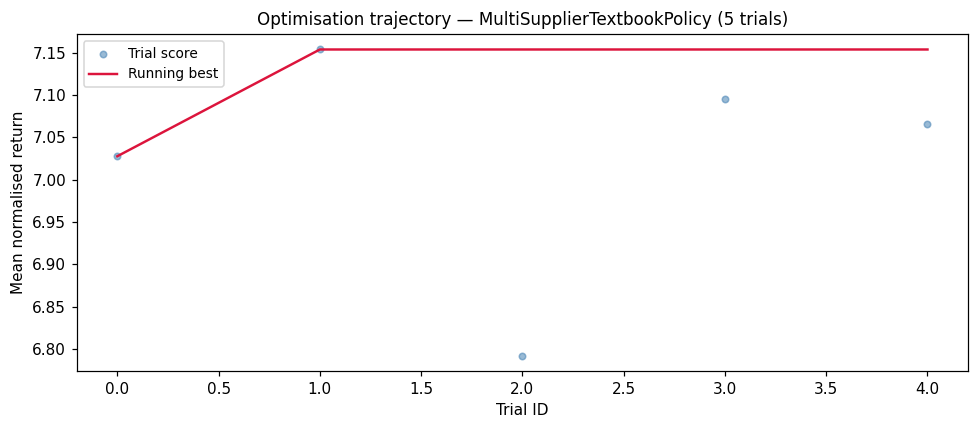

Best mean normalised return: 7.153982


In [6]:
if not _STUDY_AVAILABLE:
    print('Run: uv run python -m src.tuning.study --name smoke --trials 5')
else:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.scatter(
        trials_df['trial_id'], trials_df['mean_normalised_return'],
        s=18, alpha=0.55, color='steelblue', label='Trial score',
    )
    running_best = trials_df['mean_normalised_return'].cummax()
    ax.plot(trials_df['trial_id'], running_best, color='crimson', lw=1.6, label='Running best')
    ax.set_xlabel('Trial ID')
    ax.set_ylabel('Mean normalised return')
    ax.set_title(f'Optimisation trajectory — MultiSupplierTextbookPolicy ({len(trials_df)} trials)')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f'Best mean normalised return: {trials_df["mean_normalised_return"].max():.6f}')

## 6. Parameter sensitivity scatters

Each tunable on the x-axis, mean normalised return on the y-axis.
Points coloured by trial order (blue = early, yellow = late).

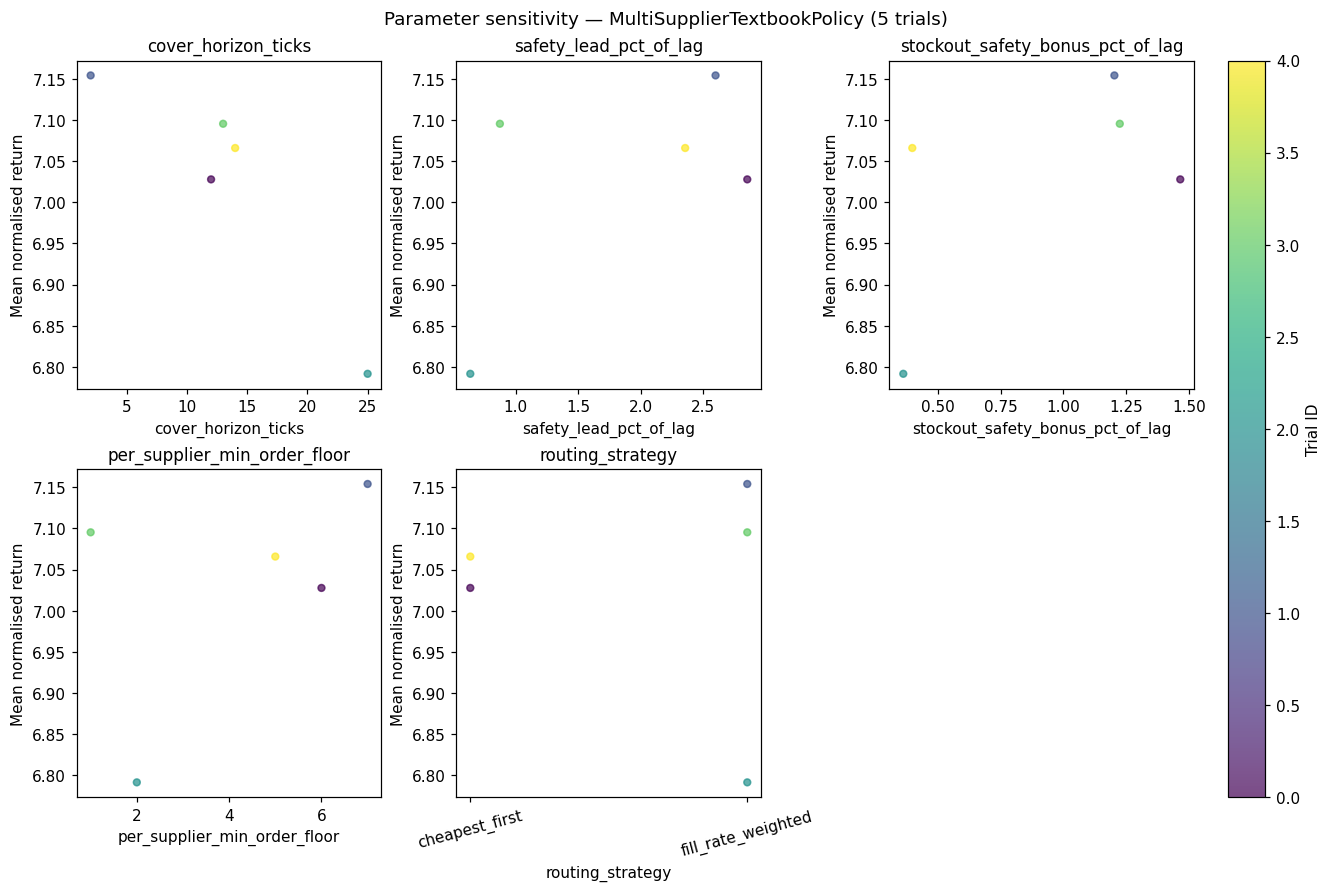

In [7]:
if not _STUDY_AVAILABLE:
    print('Run: uv run python -m src.tuning.study --name smoke --trials 5')
else:
    # Identify tunable columns present in this study's trials.parquet.
    candidate_params = [
        'cover_horizon_ticks', 'safety_lead_pct_of_lag',
        'stockout_safety_bonus_pct_of_lag',
        'per_supplier_min_order_floor', 'routing_strategy',
    ]
    param_cols = [p for p in candidate_params if p in trials_df.columns]

    if not param_cols:
        print('No tunable parameter columns found in trials.parquet.')
    else:
        n_params = len(param_cols)
        n_cols = 3
        n_rows = (n_params + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows), constrained_layout=True)
        axes_flat = axes.ravel() if hasattr(axes, 'ravel') else [axes]

        sc = None
        for ax, col in zip(axes_flat, param_cols):
            # For categorical columns, jitter x slightly.
            x_vals = trials_df[col]
            try:
                x_vals = x_vals.astype(float)
            except (ValueError, TypeError):
                # Categorical: encode as integer.
                cats = sorted(x_vals.dropna().unique())
                x_vals = x_vals.map({c: i for i, c in enumerate(cats)})
                ax.set_xticks(range(len(cats)))
                ax.set_xticklabels(cats, rotation=15)
            sc = ax.scatter(
                x_vals, trials_df['mean_normalised_return'],
                c=trials_df['trial_id'], cmap='viridis', s=20, alpha=0.7,
            )
            ax.set_xlabel(col)
            ax.set_ylabel('Mean normalised return')
            ax.set_title(col)

        for ax in axes_flat[n_params:]:
            ax.set_visible(False)

        if sc is not None:
            fig.colorbar(sc, ax=axes_flat[:n_params], label='Trial ID', pad=0.02)
        fig.suptitle(f'Parameter sensitivity — MultiSupplierTextbookPolicy ({len(trials_df)} trials)')
        plt.show()

## 7. Pareto front: profit vs service level

Scatter of all trials by `(mean_service_level, mean_net_profit)`. Pareto-non-dominated
points highlighted in red.

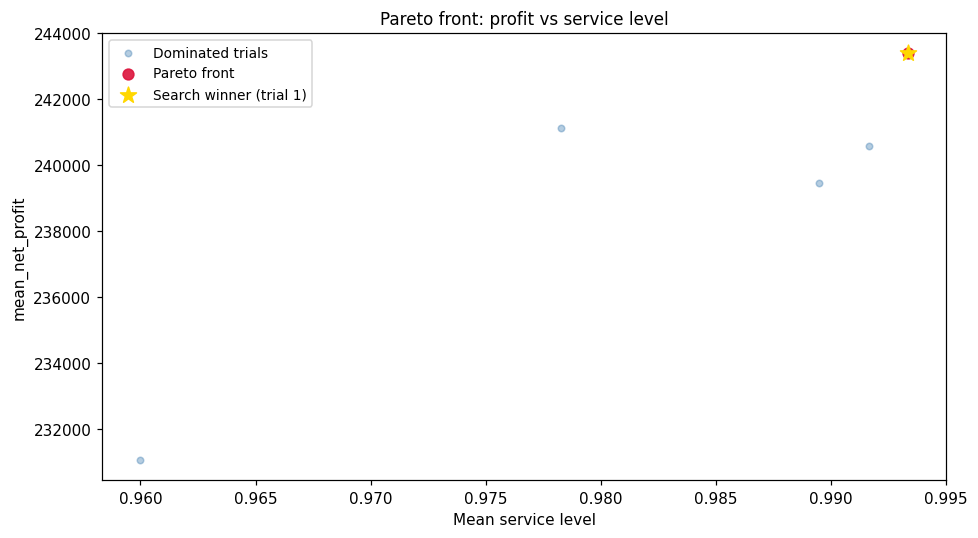

Pareto-non-dominated trials: 1 / 5


In [8]:
if not _STUDY_AVAILABLE:
    print('Run: uv run python -m src.tuning.study --name smoke --trials 5')
else:
    profit_col  = 'mean_net_profit' if 'mean_net_profit' in trials_df.columns else 'mean_normalised_return'
    service_col = 'mean_service_level' if 'mean_service_level' in trials_df.columns else None

    if service_col is None:
        print('mean_service_level column not found in trials.parquet — skipping Pareto plot.')
    else:
        profit_vals  = trials_df[profit_col].values
        service_vals = trials_df[service_col].values
        n = len(profit_vals)
        dominated = np.zeros(n, dtype=bool)
        for i in range(n):
            for j in range(n):
                if i == j:
                    continue
                if (profit_vals[j] >= profit_vals[i] and
                        service_vals[j] >= service_vals[i] and
                        (profit_vals[j] > profit_vals[i] or service_vals[j] > service_vals[i])):
                    dominated[i] = True
                    break
        pareto_mask = ~dominated
        # best_trial_id is an Optuna trial id, not a row position — locate the winner
        # row by trial_id so the marker is correct even if trials are reordered/filtered.
        best_trial_id = int(study_meta['best_trial_id'])
        winner = trials_df.loc[trials_df['trial_id'] == best_trial_id]

        fig, ax = plt.subplots(figsize=(9, 5))
        ax.scatter(service_vals[~pareto_mask], profit_vals[~pareto_mask],
                   s=18, alpha=0.4, color='steelblue', label='Dominated trials')
        ax.scatter(service_vals[pareto_mask], profit_vals[pareto_mask],
                   s=50, alpha=0.9, color='crimson', zorder=5, label='Pareto front')
        ax.scatter(winner[service_col].values, winner[profit_col].values,
                   s=120, marker='*', color='gold', zorder=6,
                   label=f'Search winner (trial {best_trial_id})')
        ax.set_xlabel('Mean service level')
        ax.set_ylabel(profit_col)
        ax.set_title('Pareto front: profit vs service level')
        ax.legend()
        plt.tight_layout()
        plt.show()
        print(f'Pareto-non-dominated trials: {pareto_mask.sum()} / {n}')

## 8. Scale robustness: per-capacity-bucket paired bar

If holdout artifacts exist, bucket the held-out seeds by capacity into terciles
and compare tuned vs published default.

In [9]:
holdout_path = study_dir / 'holdout.parquet' if _STUDY_AVAILABLE else None

if not _STUDY_AVAILABLE or holdout_path is None or not holdout_path.exists():
    print('No holdout.parquet found.')
    print('Run confirm_top_k() or use --confirm in the study CLI to generate holdout artifacts.')
else:
    holdout_df = pd.read_parquet(holdout_path)
    with open(study_dir / 'holdout_summary.json') as fh:
        holdout_summary = json.load(fh)

    best_label = holdout_summary.get('tuned_best_label', 'tuned_rank_1')

    if 'capacity' not in holdout_df.columns:
        print('capacity column not in holdout.parquet — skipping bucket plot.')
    else:
        ho = holdout_df[holdout_df['label'].isin([best_label, 'default'])].copy()
        ho['cap_bucket'] = pd.qcut(ho['capacity'], q=3, labels=['small', 'medium', 'large'])

        winner_by_bucket = ho[ho['label'] == best_label].groupby('cap_bucket', observed=True)['net_profit'].mean()
        default_by_bucket = ho[ho['label'] == 'default'].groupby('cap_bucket', observed=True)['net_profit'].mean()

        buckets = ['small', 'medium', 'large']
        x = np.arange(len(buckets))
        bar_w = 0.35

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.bar(x - bar_w / 2, [winner_by_bucket.get(b, 0) for b in buckets],
               bar_w, color='steelblue', alpha=0.85, label=f'Tuned ({best_label})')
        ax.bar(x + bar_w / 2, [default_by_bucket.get(b, 0) for b in buckets],
               bar_w, color='darkorange', alpha=0.85, label='Published default')
        ax.set_xticks(x)
        ax.set_xticklabels(['Small capacity', 'Medium capacity', 'Large capacity'])
        ax.set_ylabel('Mean net profit')
        ax.set_title('Scale robustness: per-capacity-bucket mean net profit (held-out seeds)')
        ax.legend()
        plt.tight_layout()
        plt.show()

No holdout.parquet found.
Run confirm_top_k() or use --confirm in the study CLI to generate holdout artifacts.


## 9. Closing — follow-up directions

**Graph-engine updates:**
- The per-trial CRN tuple now includes the `allocation` sub-seed (ADR 0016), so
  paired comparisons are bit-identical on the graph engine.
- Two new tunables (`per_supplier_min_order_floor`, `routing_strategy`) extend the
  search space. Both are searched in the same Optuna trial alongside the legacy parameters.
- The rollout builds a 3-node degenerate graph (1 factory → 1 shop → K sinks) per
  episode — identical to the RL training topology.

**Explicitly out of scope** (recorded in [ADR 0009](../docs/adr/0009-policy-hyperparameter-tuning-tool.md)):
- Per-world or per-scale tuning (framings 2 and 3)
- Multi-objective Optuna (NSGA-II)
- Tuning across multiple echelon topologies
- SQLite-backed study (swap `storage=None` for a file URI to enable `optuna-dashboard`)

**Next steps:**
- Compare the tuned `OrderUpToPolicy` against the RL agent on the same held-out seeds
  (see `notebooks/09-rl-vs-baseline.ipynb`).
- Run `confirm_top_k()` on the search winners to get holdout.parquet for section 8.